In [1]:
import pandas as pd
df = pd.read_csv("house_prices.csv")

In [2]:
print(df.head())

  Property_ID  Area  Bedrooms  Bathrooms  Age     Location Property_Type  \
0    PROP0001  3712         4          3   36        Rural         House   
1    PROP0002  1591         4          1   35       Suburb         House   
2    PROP0003  1646         4          3   20        Rural         Villa   
3    PROP0004  4814         1          2   13  City Center         Villa   
4    PROP0005   800         4          2   38       Suburb     Apartment   

      Price  
0  22260000  
1  16057500  
2  12730000  
3  50840000  
4  10650000  


In [3]:
print(df.isnull().sum())

Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64


In [4]:
print(df.dtypes)

Property_ID      object
Area              int64
Bedrooms          int64
Bathrooms         int64
Age               int64
Location         object
Property_Type    object
Price             int64
dtype: object


In [5]:
df = df.drop(['Property_Type'], axis=1)  # or similar column

In [6]:
df = pd.get_dummies(df, drop_first=True)

In [7]:
print(df.columns)

Index(['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Price', 'Property_ID_PROP0002',
       'Property_ID_PROP0003', 'Property_ID_PROP0004', 'Property_ID_PROP0005',
       'Property_ID_PROP0006',
       ...
       'Property_ID_PROP0293', 'Property_ID_PROP0294', 'Property_ID_PROP0295',
       'Property_ID_PROP0296', 'Property_ID_PROP0297', 'Property_ID_PROP0298',
       'Property_ID_PROP0299', 'Property_ID_PROP0300', 'Location_Rural',
       'Location_Suburb'],
      dtype='object', length=306)


In [8]:
df = df.loc[:, ~df.columns.str.startswith('Property_ID')]

In [10]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
predictions = model.predict(X_test)

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 1957819.4322350805
MSE: 7366554518302.611
R2 Score: 0.9537247685702549


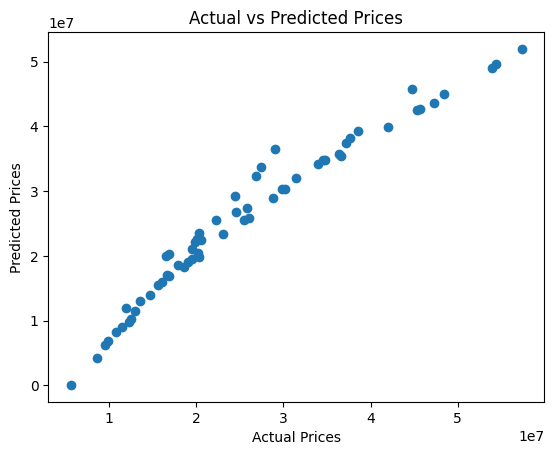

In [14]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.savefig("predictions_vs_actual.png")  # Save image
plt.show()